# Tree-Based Methods

**Decision Trees, Random Forests, and Gradient Boosting**

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain how decision trees partition feature space via **recursive binary splitting** and predict a constant within each region.
2. Define and compute the standard **impurity measures** — Gini index, entropy, and MSE — and explain why they drive the splitting criterion.
3. **Implement a simple CART regressor from scratch** in plain NumPy and verify it against scikit-learn.
4. Understand **Random Forests** as a variance-reduction strategy that combines bagging with random feature subsampling.
5. Understand **Gradient Boosting** as sequential fitting of shallow trees to pseudo-residuals, and connect it to gradient descent in function space.
6. Use scikit-learn's tree ensemble models (`RandomForestRegressor`, `GradientBoostingRegressor`, `HistGradientBoostingRegressor`) effectively.
7. Interpret **feature importances** correctly and understand their limitations.

### Prerequisites

- Familiarity with linear regression and the bias-variance tradeoff (Module 06, Module 11 Notebook 01).
- Basic probability and expectation.
- Comfort with NumPy and matplotlib.

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.datasets import make_moons

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Decision Trees — Recursive Partitioning

### 1.1 The Core Idea

A **decision tree** is a supervised learning model that predicts the output $y$ for an input $\mathbf{x} \in \mathbb{R}^p$ by recursively partitioning the feature space into **axis-aligned rectangular regions** $R_1, R_2, \ldots, R_J$ and assigning a constant prediction $\hat{y}_j$ within each region.

Formally, the model is:

$$
\hat{f}(\mathbf{x}) = \sum_{j=1}^{J} \hat{y}_j \, \mathbf{1}(\mathbf{x} \in R_j)
$$

where $\mathbf{1}(\cdot)$ is the indicator function and the regions $\{R_j\}_{j=1}^J$ form a partition of the feature space (they are mutually exclusive and collectively exhaustive).

The key constraint is that these regions are produced by **recursive binary splitting** — each region is split into exactly two child regions by a rule of the form:

$$
x_j \leq s \quad \text{vs.} \quad x_j > s
$$

for some feature index $j \in \{1, \ldots, p\}$ and threshold $s \in \mathbb{R}$. This produces a binary tree whose **internal nodes** are splitting rules and whose **leaves** (terminal nodes) are the regions $R_j$.

### 1.2 Regression Trees

For a regression problem, the prediction in each leaf is simply the **mean** of the training responses that fall into that region:

$$
\hat{y}_j = \frac{1}{|R_j|} \sum_{i: \, \mathbf{x}_i \in R_j} y_i
$$

The loss function driving the splits is the **residual sum of squares** (RSS) summed across all regions:

$$
\text{RSS} = \sum_{j=1}^{J} \sum_{i: \, \mathbf{x}_i \in R_j} (y_i - \hat{y}_j)^2
$$

Finding the globally optimal partition (the one that minimises RSS over all possible binary trees) is computationally infeasible — it is NP-hard. Instead, decision trees use a **greedy, top-down** approach: at each step, find the single split that reduces RSS the most.

### 1.3 The Splitting Criterion — Regression

Suppose we are considering splitting a region $R$ (containing $n_R$ training points) into two child regions:

$$
R_L(j, s) = \{\mathbf{x} : x_j \leq s\}, \qquad R_R(j, s) = \{\mathbf{x} : x_j > s\}
$$

The optimal split $(j^*, s^*)$ solves:

$$
(j^*, s^*) = \arg\min_{j, s} \left[ \sum_{i: \, \mathbf{x}_i \in R_L(j,s)} (y_i - \bar{y}_L)^2 + \sum_{i: \, \mathbf{x}_i \in R_R(j,s)} (y_i - \bar{y}_R)^2 \right]
$$

where $\bar{y}_L$ and $\bar{y}_R$ are the means of the responses in the left and right children, respectively. For a given feature $j$, we only need to check at most $n_R - 1$ candidate thresholds (the midpoints between consecutive sorted values), so the search over all features and thresholds is $O(p \cdot n_R \log n_R)$ per split.

### 1.4 Classification Trees — Impurity Measures

For classification with $K$ classes, each leaf predicts the **majority class** among training points in that region. But we need a measure of **node impurity** — how mixed the class labels are — to decide where to split.

Let $\hat{p}_k$ be the proportion of training observations in a node that belong to class $k$.

**Gini Index:**

$$
G(\hat{p}_1, \ldots, \hat{p}_K) = \sum_{k=1}^{K} \hat{p}_k (1 - \hat{p}_k) = 1 - \sum_{k=1}^{K} \hat{p}_k^2
$$

The Gini index measures the probability that a randomly chosen sample from the node would be misclassified if we labelled it by randomly drawing a label according to the class distribution in that node. It is maximised when all classes are equally represented ($G = 1 - 1/K$) and minimised (zero) when the node is pure.

**Entropy (Information Gain):**

$$
H(\hat{p}_1, \ldots, \hat{p}_K) = -\sum_{k=1}^{K} \hat{p}_k \log_2 \hat{p}_k
$$

with the convention $0 \log_2 0 = 0$. Entropy is the expected number of bits needed to encode the class label. Like Gini, it is zero for pure nodes and maximal for uniform distributions.

**Classification Error Rate:**

$$
E = 1 - \max_k \hat{p}_k
$$

This is the simplest measure but is **not differentiable** at the boundaries and is less sensitive to changes in class probabilities. It is rarely used for growing trees (Gini and entropy are preferred) but is used for **pruning** and final evaluation.

### 1.5 Weighted Impurity for Splits

When evaluating a candidate split of node $t$ into children $t_L$ and $t_R$, we compute the **weighted average impurity**:

$$
\Delta I(t) = I(t) - \frac{n_L}{n_t} I(t_L) - \frac{n_R}{n_t} I(t_R)
$$

where $I(\cdot)$ is either Gini or entropy, $n_t$ is the number of samples in node $t$, and $n_L, n_R$ are the sample counts in the children. We choose the split that **maximises** $\Delta I(t)$ (equivalently, minimises the weighted child impurity).

### Visualising Impurity Measures

Before we look at a tree in action, let us plot the three impurity measures as a function of $p_1$ for a binary classification problem ($K = 2$). This helps build intuition for why Gini and entropy are preferred over the classification error rate: they are more "curved" near the extremes, making them more sensitive to improvements in purity.

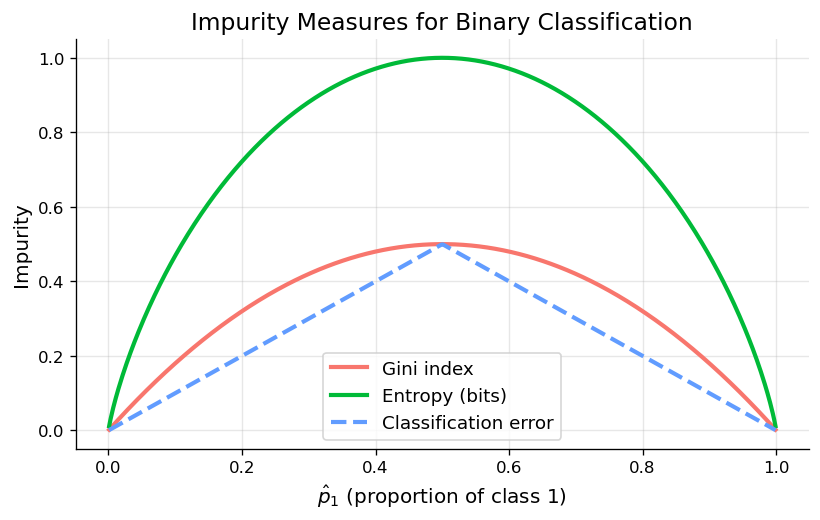

In [ ]:
p = np.linspace(0.001, 0.999, 500)

gini = 2 * p * (1 - p)  # K=2 Gini
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
class_err = 1 - np.maximum(p, 1 - p)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p, gini, color=SALMON, lw=2.5, label="Gini index")
ax.plot(p, entropy, color=EMERALD, lw=2.5, label="Entropy (bits)")
ax.plot(p, class_err, color=PERIWINKLE, lw=2.5, ls="--", label="Classification error")
ax.set_xlabel(r"$\hat{p}_1$ (proportion of class 1)")
ax.set_ylabel("Impurity")
ax.set_title("Impurity Measures for Binary Classification")
ax.legend()
plt.tight_layout()
plt.show()

All three measures peak at $\hat{p}_1 = 0.5$ (maximum uncertainty) and are zero at the extremes (pure nodes). Notice that the Gini index and entropy are both more "sensitive" in the tails — small changes in class proportion near a pure node produce larger changes in Gini/entropy than in the classification error rate. This is why they are better objective functions for tree growing: they can detect improvements in purity that the error rate misses.

### A Decision Tree on the Moons Dataset

Let us fit a decision tree classifier to a 2D classification problem to see how the tree partitions the feature space. We use scikit-learn's `make_moons` dataset — two interleaving half-circles — and fit a tree with `max_depth=4`. The decision boundary plot below shows the axis-aligned rectangular regions that the tree creates, coloured by predicted class.

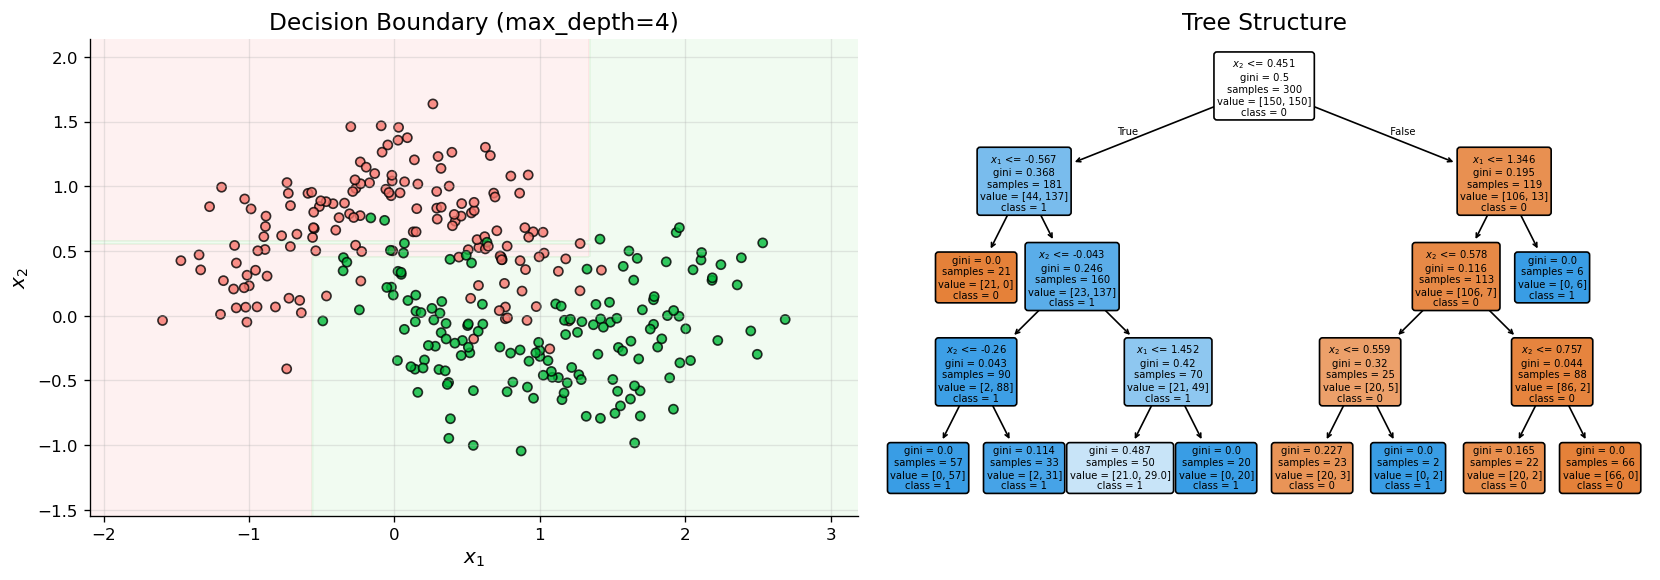

In [ ]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_moons, y_moons)

# Decision boundary meshgrid
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_light = ListedColormap(["#FDDEDE", "#DEF5DE"])
cmap_bold = ListedColormap([SALMON, EMERALD])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: decision boundary
axes[0].contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
axes[0].scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=y_moons,
    cmap=cmap_bold,
    edgecolors="k",
    s=30,
    alpha=0.8,
)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_title("Decision Boundary (max_depth=4)")

# Right: tree diagram
plot_tree(
    tree_clf,
    filled=True,
    rounded=True,
    ax=axes[1],
    feature_names=["$x_1$", "$x_2$"],
    fontsize=6,
    class_names=["0", "1"],
)
axes[1].set_title("Tree Structure")

plt.tight_layout()
plt.show()

On the left, observe the **axis-aligned** rectangular decision regions — this is the fundamental geometric constraint of decision trees. Each split is a horizontal or vertical line (in 2D). On the right, the tree diagram shows the splitting rules at each internal node, the Gini impurity, the sample count, and the predicted class.

---

## 2. Growing and Pruning

### 2.1 The Recursive Splitting Algorithm

The CART (Classification and Regression Trees) algorithm grows a tree as follows:

1. Start with the entire dataset as the root node.
2. For the current node, search over all features $j$ and all thresholds $s$ to find the split that minimises the impurity (or MSE for regression).
3. Split the node into two children based on the optimal $(j^*, s^*)$.
4. Recursively repeat steps 2--3 on each child node.
5. Stop when a **stopping criterion** is met.

This is a **greedy** algorithm — each split is locally optimal but may not produce the globally best tree.

### 2.2 Stopping Criteria

Common stopping criteria include:

- **Maximum depth** (`max_depth`): limit the number of levels in the tree.
- **Minimum samples per leaf** (`min_samples_leaf`): do not create a leaf with fewer than $m$ samples.
- **Minimum impurity decrease** (`min_impurity_decrease`): only split if the impurity reduction exceeds a threshold $\delta$.
- **Maximum number of leaf nodes** (`max_leaf_nodes`).

### 2.3 Overfitting

A fully grown tree (no stopping criteria) will create one leaf per training point, achieving **zero training error** but terrible generalisation. This is a textbook case of **overfitting** — the model memorises the training data, including its noise.

The figure below demonstrates this progression: as `max_depth` increases, the decision boundary becomes increasingly jagged and fits the noise.

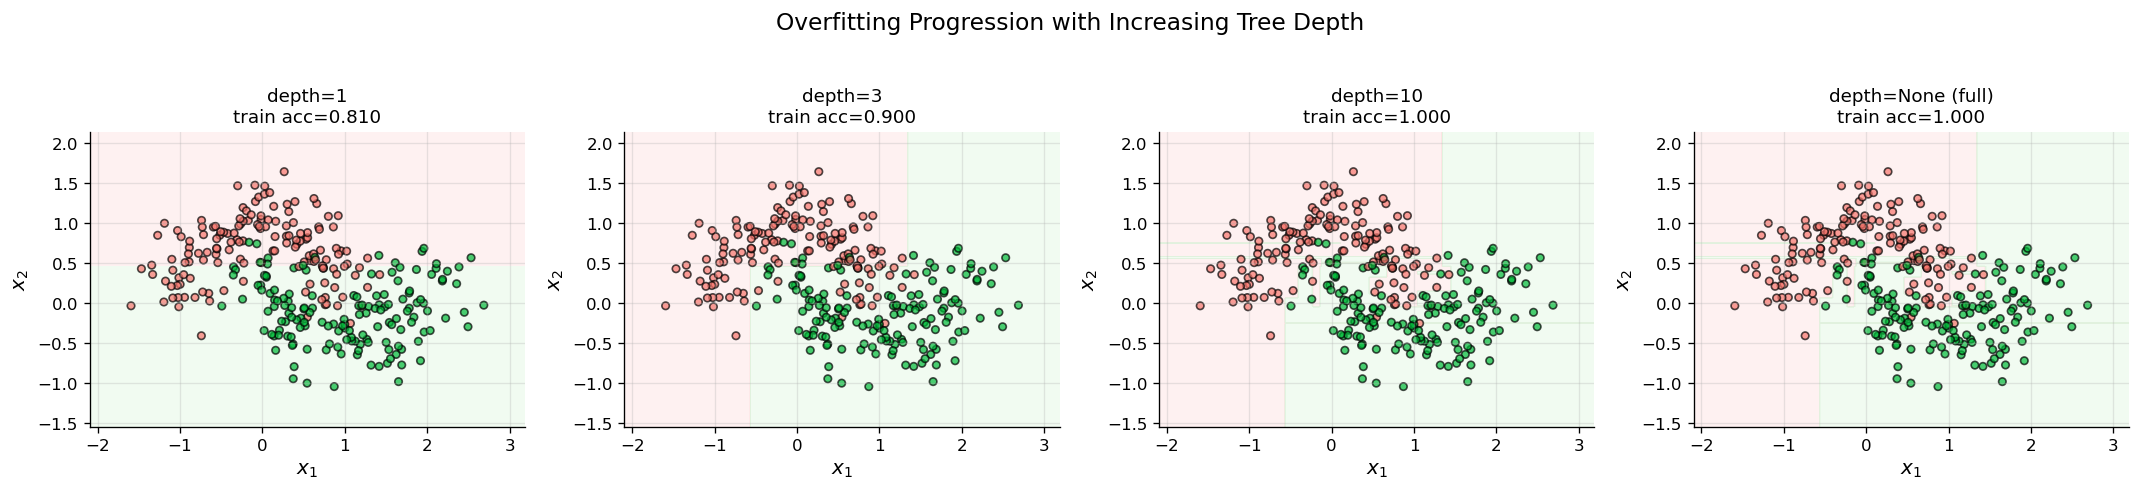

In [ ]:
depths = [1, 3, 10, None]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, depth in zip(axes, depths):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_moons, y_moons)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
    ax.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=y_moons,
        cmap=cmap_bold,
        edgecolors="k",
        s=20,
        alpha=0.7,
    )
    train_acc = clf.score(X_moons, y_moons)
    label = str(depth) if depth is not None else "None (full)"
    ax.set_title(f"depth={label}\ntrain acc={train_acc:.3f}", fontsize=11)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.suptitle("Overfitting Progression with Increasing Tree Depth", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

At `depth=1`, the tree is a **decision stump** — a single split that underfits badly. At `depth=3`, the boundary captures the general shape of the moons. At `depth=10` and `depth=None`, the tree creates tiny isolated rectangles to classify every training point correctly, at the cost of a highly irregular boundary that will not generalise.

### 2.4 Cost-Complexity Pruning

Rather than relying solely on stopping criteria, we can grow a large tree $T_0$ and then **prune** it back. The idea is to penalise tree complexity, analogous to regularisation in linear models.

Define the **cost-complexity criterion**:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

where:
- $R(T) = \sum_{j=1}^{|T|} \sum_{i: \, \mathbf{x}_i \in R_j} (y_i - \hat{y}_j)^2$ is the total training RSS (or misclassification cost) of tree $T$,
- $|T|$ is the number of **terminal nodes** (leaves),
- $\alpha \geq 0$ is a complexity parameter.

When $\alpha = 0$, the optimal tree is the full tree $T_0$. As $\alpha$ increases, the penalty for having many leaves grows, and the optimal subtree shrinks. For each $\alpha$, there exists a unique smallest subtree $T_\alpha \subseteq T_0$ that minimises $R_\alpha(T)$.

In practice, we use **cross-validation** to choose $\alpha$: grow the full tree, compute the sequence of optimal subtrees for a range of $\alpha$ values, and pick the $\alpha$ whose subtree has the lowest CV error.

Scikit-learn implements this via `ccp_alpha` in `DecisionTreeClassifier` and `DecisionTreeRegressor`. We will not implement pruning from scratch — the key insight is that it plays the same role as $\lambda$ in Ridge/Lasso: controlling the complexity-fit tradeoff.

---

## 3. From-Scratch Decision Tree (Regression)

Following the course philosophy of building things from scratch before using professional tools, let us implement a simple **CART regression tree** in plain Python and NumPy.

### 3.1 The Algorithm

Our implementation will:

1. At each node, search all features and all candidate thresholds (midpoints of consecutive sorted values) to find the split that minimises the total MSE in the two children.
2. Recursively split until `max_depth` is reached or a node has fewer than `min_samples_leaf` samples.
3. At each leaf, predict the mean of the training $y$ values in that node.

We represent the tree as a nested dictionary of nodes.

In [ ]:
class SimpleTreeRegressor:
    """Minimal CART regression tree built from scratch."""

    def __init__(self, max_depth=5, min_samples_leaf=2):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.tree_ = None

    # ----- fitting --------------------------------------------------------
    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
        self.tree_ = self._build(X, y, depth=0)
        return self

    def _build(self, X, y, depth):
        n = len(y)
        node_pred = y.mean()

        # Stopping conditions
        if depth >= self.max_depth or n < 2 * self.min_samples_leaf:
            return {"leaf": True, "pred": node_pred}

        best_mse = np.inf
        best_j, best_s = None, None

        for j in range(X.shape[1]):
            # Sort by feature j
            order = np.argsort(X[:, j])
            X_sorted, y_sorted = X[order], y[order]

            # Candidate thresholds: midpoints of consecutive unique values
            vals = X_sorted[:, j]
            # Efficient cumulative sums for MSE computation
            cum_sum = np.cumsum(y_sorted)
            cum_sq_sum = np.cumsum(y_sorted**2)

            for i in range(self.min_samples_leaf, n - self.min_samples_leaf):
                if vals[i] == vals[i - 1]:  # skip duplicate thresholds
                    continue
                s = 0.5 * (vals[i - 1] + vals[i])
                n_L = i
                n_R = n - i

                # MSE_L = (1/n_L) * sum(y_i^2) - mean_L^2
                mean_L = cum_sum[i - 1] / n_L
                mse_L = cum_sq_sum[i - 1] / n_L - mean_L**2

                mean_R = (cum_sum[-1] - cum_sum[i - 1]) / n_R
                mse_R = (cum_sq_sum[-1] - cum_sq_sum[i - 1]) / n_R - mean_R**2

                weighted_mse = n_L * mse_L + n_R * mse_R

                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_j = j
                    best_s = s

        # No valid split found
        if best_j is None:
            return {"leaf": True, "pred": node_pred}

        left_mask = X[:, best_j] <= best_s
        right_mask = ~left_mask

        return {
            "leaf": False,
            "feature": best_j,
            "threshold": best_s,
            "left": self._build(X[left_mask], y[left_mask], depth + 1),
            "right": self._build(X[right_mask], y[right_mask], depth + 1),
        }

    # ----- prediction -----------------------------------------------------
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def _predict_one(self, x, node):
        if node["leaf"]:
            return node["pred"]
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])


print("SimpleTreeRegressor class defined.")

SimpleTreeRegressor class defined.


### 3.2 Testing on Synthetic 1D Data

We generate data from a nonlinear function $f(x) = \sin(3x) + 0.5x$ with Gaussian noise, fit our from-scratch tree, and plot the resulting step-function predictions. A regression tree's prediction surface is always a **piecewise-constant function** — flat within each leaf region.

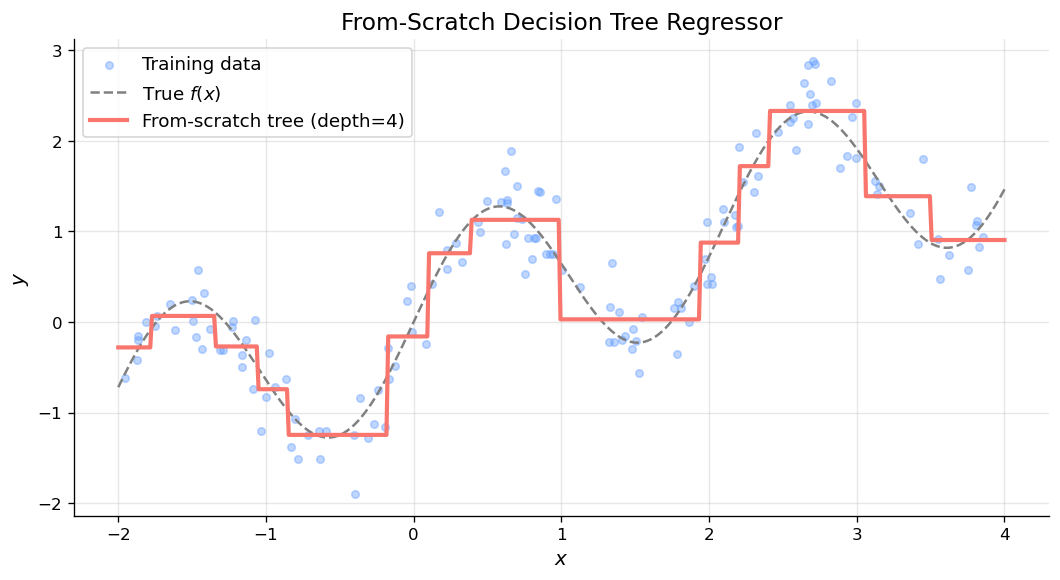

In [ ]:
# Synthetic 1D regression data
n_pts = 150
X_1d = rng.uniform(-2, 4, size=(n_pts, 1))
y_1d = np.sin(3 * X_1d[:, 0]) + 0.5 * X_1d[:, 0] + rng.normal(0, 0.3, n_pts)

# Fit our from-scratch tree
scratch_tree = SimpleTreeRegressor(max_depth=4, min_samples_leaf=5)
scratch_tree.fit(X_1d, y_1d)

# Predictions on a fine grid
X_grid = np.linspace(-2, 4, 500).reshape(-1, 1)
y_scratch = scratch_tree.predict(X_grid)
y_true = np.sin(3 * X_grid[:, 0]) + 0.5 * X_grid[:, 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_1d[:, 0], y_1d, alpha=0.4, s=20, color=PERIWINKLE, label="Training data")
ax.plot(X_grid[:, 0], y_true, color="grey", lw=1.5, ls="--", label="True $f(x)$")
ax.plot(
    X_grid[:, 0], y_scratch, color=SALMON, lw=2.5, label="From-scratch tree (depth=4)"
)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("From-Scratch Decision Tree Regressor")
ax.legend()
plt.tight_layout()
plt.show()

The step-function shape is clearly visible: the tree has carved the $x$-axis into segments and predicts a constant (the local mean) within each segment. Deeper trees would produce more, narrower steps — better approximating the smooth true function but also risking overfitting.

### 3.3 Comparison with scikit-learn

Let us verify that our from-scratch implementation produces the same (or very similar) predictions as scikit-learn's `DecisionTreeRegressor` with the same hyperparameters.

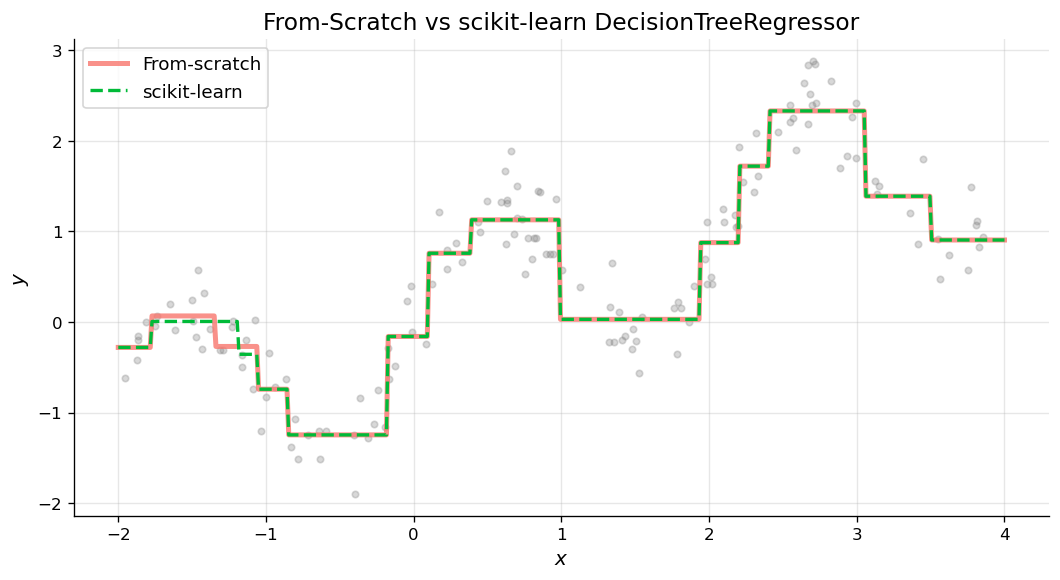

Maximum absolute difference between predictions: 0.275977


In [7]:
# scikit-learn tree with same settings
sk_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42)
sk_tree.fit(X_1d, y_1d)
y_sklearn = sk_tree.predict(X_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(X_grid[:, 0], y_scratch, color=SALMON, lw=3, label="From-scratch", alpha=0.8)
ax.plot(X_grid[:, 0], y_sklearn, color=EMERALD, lw=2, ls="--", label="scikit-learn")
ax.scatter(X_1d[:, 0], y_1d, alpha=0.3, s=15, color="grey")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("From-Scratch vs scikit-learn DecisionTreeRegressor")
ax.legend()
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(y_scratch - y_sklearn))
print(f"Maximum absolute difference between predictions: {max_diff:.6f}")

The two curves should overlay almost perfectly. Small numerical differences may arise from tie-breaking in threshold selection, but the overall prediction surface is the same. This confirms that our from-scratch implementation correctly captures the CART algorithm.

---

## 4. Random Forests — Variance Reduction Through Ensembling

### 4.1 The Variance Problem with Single Trees

Decision trees suffer from **high variance**: small changes in the training data can produce a completely different tree structure and very different predictions. This makes them unreliable as standalone predictors.

The key insight of ensemble methods is that we can **reduce variance without increasing bias** by averaging many high-variance, low-bias models.

### 4.2 Bagging (Bootstrap Aggregating)

**Bagging** (Breiman, 1996) is the simplest ensemble approach:

1. Draw $B$ **bootstrap samples** $\mathcal{D}_1^*, \ldots, \mathcal{D}_B^*$ from the training data (each of size $n$, sampled with replacement).
2. Fit a full (unpruned) decision tree $\hat{f}_b$ to each bootstrap sample.
3. Average the predictions:

$$
\hat{f}_{\text{bag}}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}_b(\mathbf{x})
$$

For classification, we use **majority voting** instead of averaging.

**Why does this work?** Consider $B$ identically distributed random variables $Z_1, \ldots, Z_B$, each with variance $\sigma^2$ and pairwise correlation $\rho$. The variance of their mean is:

$$
\text{Var}\!\left(\frac{1}{B}\sum_{b=1}^B Z_b\right) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2
$$

As $B \to \infty$, the second term vanishes, but the first term — $\rho \sigma^2$ — remains. This is the irreducible ensemble variance, and it is proportional to the **correlation** between individual trees.

### 4.3 Random Feature Subsampling

**Random Forests** (Breiman, 2001) extend bagging with one crucial modification: at each split, only a random subset of $m$ features (out of $p$ total) is considered as candidates. This **decorrelates** the trees.

Why? If one feature is very strong, every bagged tree will split on it first, producing highly correlated trees ($\rho$ close to 1). By restricting each split to a random subset, we force trees to explore different features, reducing $\rho$ and thereby reducing ensemble variance.

Typical choices for $m$:
- **Regression:** $m \approx p/3$
- **Classification:** $m \approx \sqrt{p}$

The ensemble variance formula becomes concrete:

$$
\text{Var}\!\left(\hat{f}_{\text{RF}}\right) \approx \rho_{\text{RF}} \sigma^2 + \frac{1 - \rho_{\text{RF}}}{B} \sigma^2
$$

where $\rho_{\text{RF}} < \rho_{\text{bag}}$ because the feature subsampling decorrelates the trees. This is the fundamental reason Random Forests outperform simple bagging.

### Simulation: Individual Trees vs Random Forest

The following simulation illustrates the variance reduction visually. We fit 100 individual decision trees on bootstrap samples from our 1D data, plot each tree's predictions (high variance, shown as faint lines), and overlay the Random Forest prediction (their average — smooth and stable).

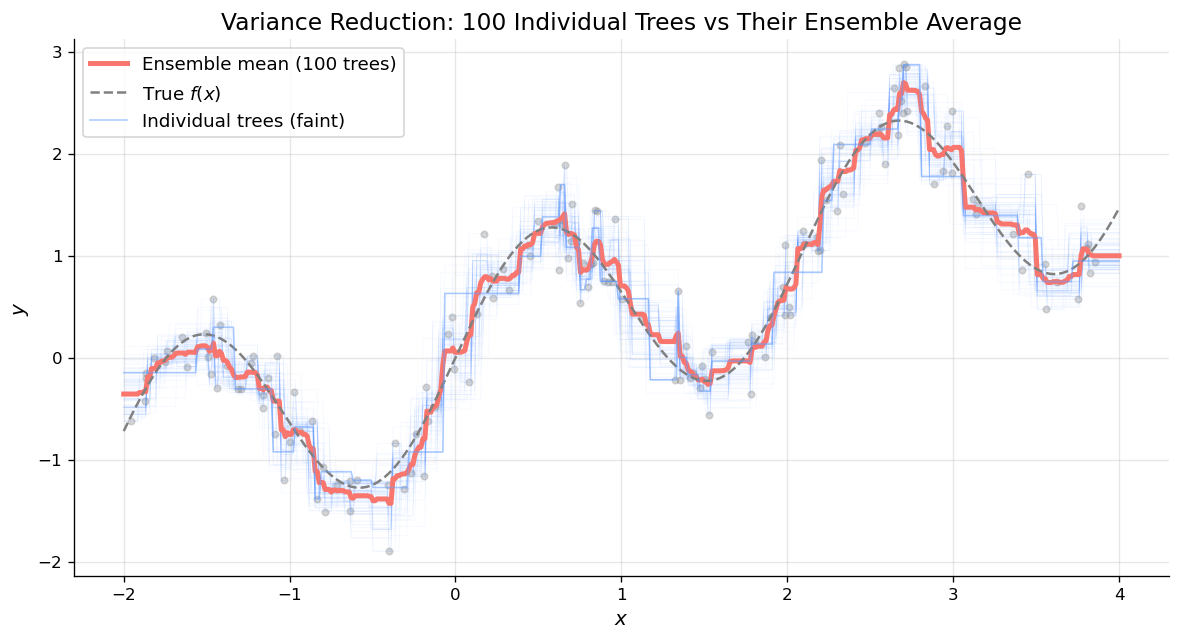

In [ ]:
B = 100  # number of trees
individual_preds = np.zeros((B, len(X_grid)))

for b in range(B):
    # Bootstrap sample
    idx = rng.choice(n_pts, size=n_pts, replace=True)
    X_boot, y_boot = X_1d[idx], y_1d[idx]
    tree_b = DecisionTreeRegressor(max_depth=None, min_samples_leaf=3, random_state=b)
    tree_b.fit(X_boot, y_boot)
    individual_preds[b] = tree_b.predict(X_grid)

rf_pred = individual_preds.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5.5))
for b in range(B):
    ax.plot(X_grid[:, 0], individual_preds[b], color=PERIWINKLE, alpha=0.06, lw=0.5)
ax.plot(X_grid[:, 0], rf_pred, color=SALMON, lw=3, label=f"Ensemble mean ({B} trees)")
ax.plot(X_grid[:, 0], y_true, color="grey", lw=1.5, ls="--", label="True $f(x)$")
ax.scatter(X_1d[:, 0], y_1d, alpha=0.3, s=15, color="grey", zorder=0)
# One individual tree for contrast
ax.plot(
    X_grid[:, 0],
    individual_preds[0],
    color=PERIWINKLE,
    alpha=0.5,
    lw=1,
    label="Individual trees (faint)",
)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Variance Reduction: 100 Individual Trees vs Their Ensemble Average")
ax.legend()
plt.tight_layout()
plt.show()

The faint blue lines show the individual tree predictions — each is a jagged step function that varies wildly from tree to tree. The red ensemble average is much smoother and closer to the true function (dashed grey). This is bagging's variance reduction in action.

### 4.4 Out-of-Bag (OOB) Error

An elegant feature of bagging is that we get a **free cross-validation estimate** without needing to set aside a validation set.

Each bootstrap sample includes roughly $1 - 1/e \approx 63.2\%$ of the original data points. The remaining $\sim 36.8\%$ are called the **out-of-bag (OOB) samples** for that tree.

For each training point $i$, we can compute its prediction using only those trees for which point $i$ was OOB. The resulting OOB predictions give an unbiased estimate of the generalisation error — comparable to leave-one-out cross-validation but essentially free.

We demonstrate this with scikit-learn's built-in `oob_score_` attribute.

In [ ]:
rf_oob = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=3,
    oob_score=True,
    random_state=42,
)
rf_oob.fit(X_1d, y_1d)

train_mse = mean_squared_error(y_1d, rf_oob.predict(X_1d))
oob_mse = mean_squared_error(y_1d, rf_oob.oob_prediction_)

print(f"Training MSE:     {train_mse:.4f}")
print(f"OOB MSE:          {oob_mse:.4f}")
print(f"OOB R^2 (built-in): {rf_oob.oob_score_:.4f}")
print(
    f"\nThe OOB error is a reliable estimate of test error — no separate validation set needed."
)

Training MSE:     0.0570
OOB MSE:          0.1218
OOB R^2 (built-in): 0.8923

The OOB error is a reliable estimate of test error — no separate validation set needed.


---

## 5. Gradient Boosting — Sequential Learning

### 5.1 The Core Idea

While bagging (and Random Forests) builds trees **independently** and averages them, **boosting** builds trees **sequentially**, with each new tree correcting the errors of the ensemble so far.

The key idea is beautifully simple: instead of fitting a tree to the original response $y$, fit each new tree to the **residuals** — the gaps between the current ensemble's predictions and the true values.

### 5.2 The Gradient Boosting Algorithm

For regression with squared error loss, gradient boosting proceeds as follows:

**Initialise** the model with a constant:

$$
\hat{f}_0(\mathbf{x}) = \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i
$$

**For** $m = 1, 2, \ldots, M$:

1. Compute the **pseudo-residuals** (negative gradient of the loss w.r.t. the current prediction):

$$
r_i^{(m)} = y_i - \hat{f}_{m-1}(\mathbf{x}_i), \qquad i = 1, \ldots, n
$$

2. Fit a **shallow** regression tree $h_m(\mathbf{x})$ to the pseudo-residuals $\{(\mathbf{x}_i, r_i^{(m)})\}_{i=1}^n$.

3. **Update** the ensemble:

$$
\hat{f}_m(\mathbf{x}) = \hat{f}_{m-1}(\mathbf{x}) + \eta \, h_m(\mathbf{x})
$$

where $\eta \in (0, 1]$ is the **learning rate** (also called shrinkage).

**Output:** $\hat{f}_M(\mathbf{x}) = \bar{y} + \eta \sum_{m=1}^{M} h_m(\mathbf{x})$.

### 5.3 Why "Gradient"?

For the squared error loss $L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$, the negative gradient with respect to $\hat{y}$ is:

$$
-\frac{\partial L}{\partial \hat{y}} = y - \hat{y}
$$

which is exactly the residual! So fitting a tree to the residuals is equivalent to performing **gradient descent in function space** — each tree approximates the negative gradient direction, and the learning rate $\eta$ controls the step size.

For other loss functions (absolute error, Huber, log-loss for classification), the pseudo-residuals are the negative gradients of that loss, and the algorithm generalises naturally. This is what makes gradient boosting so powerful and flexible.

### 5.4 The Role of the Learning Rate

The learning rate $\eta$ controls how much each new tree contributes. Empirically, using a **small learning rate** ($\eta \approx 0.01$--$0.1$) with a **large number of trees** $M$ gives better generalisation than a large $\eta$ with few trees, because:

- Small steps prevent the ensemble from overshooting.
- More trees allows the ensemble to explore the loss surface more carefully.
- There is a regularisation effect: early stopping (choosing $M$ by cross-validation) acts as an implicit constraint.

The tradeoff is computational: small $\eta$ requires more iterations.

### Step-by-Step Gradient Boosting Visualisation

The following visualisation shows the gradient boosting process on our 1D data. We plot the ensemble's predictions after 1, 5, 20, and 100 boosting rounds, along with the current residuals. Watch how the residuals shrink as the ensemble accumulates more trees — each tree bites off a piece of the remaining error.

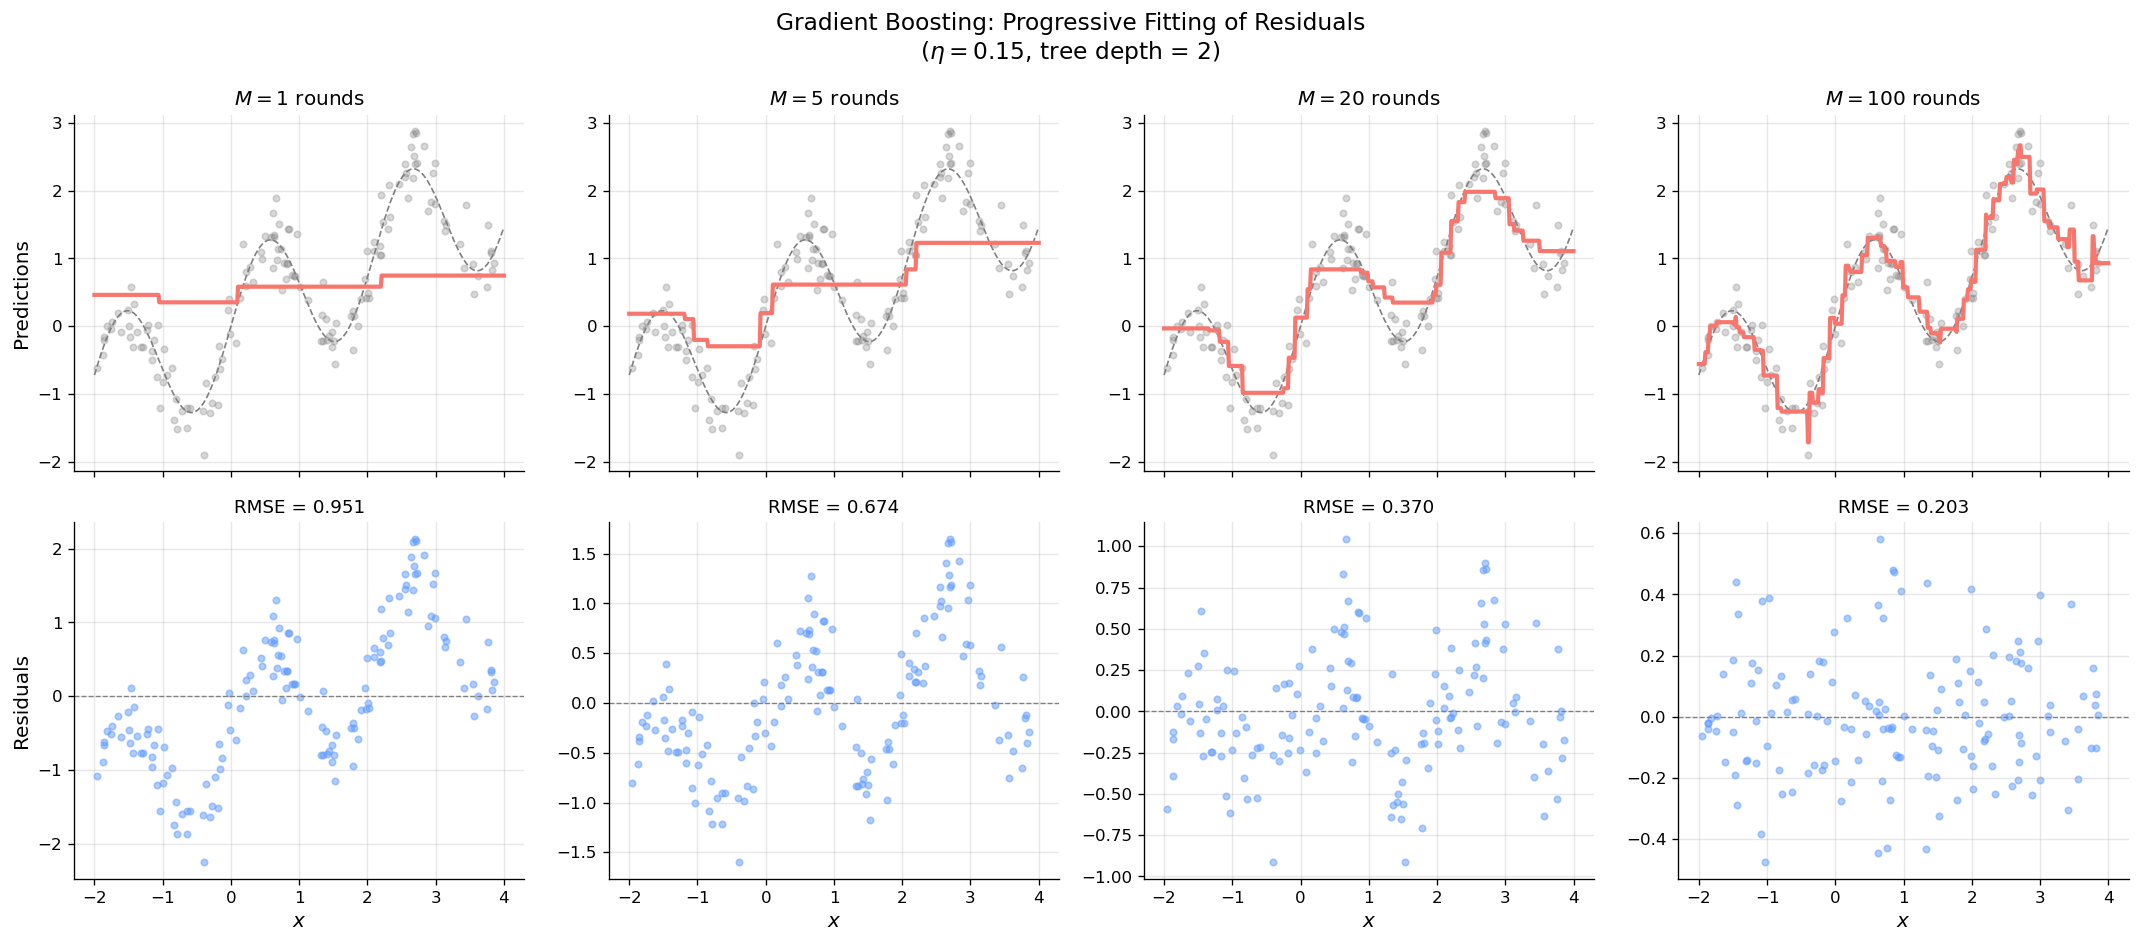

In [ ]:
# Manual gradient boosting for visualisation
eta = 0.15  # learning rate
M = 100  # total boosting rounds
tree_depth = 2

# Store predictions at each round
f_train = np.full(n_pts, y_1d.mean())  # current ensemble on training data
f_grid = np.full(len(X_grid), y_1d.mean())  # current ensemble on grid

snapshots = {1: None, 5: None, 20: None, 100: None}

for m in range(1, M + 1):
    residuals = y_1d - f_train
    h_m = DecisionTreeRegressor(max_depth=tree_depth, random_state=m)
    h_m.fit(X_1d, residuals)
    f_train += eta * h_m.predict(X_1d)
    f_grid += eta * h_m.predict(X_grid)

    if m in snapshots:
        snapshots[m] = {
            "f_grid": f_grid.copy(),
            "residuals": (y_1d - f_train).copy(),
        }

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)

for col, (m_val, snap) in enumerate(snapshots.items()):
    # Top row: predictions
    ax = axes[0, col]
    ax.scatter(X_1d[:, 0], y_1d, alpha=0.3, s=15, color="grey")
    ax.plot(X_grid[:, 0], y_true, color="grey", ls="--", lw=1)
    ax.plot(X_grid[:, 0], snap["f_grid"], color=SALMON, lw=2.5)
    ax.set_title(f"$M = {m_val}$ rounds", fontsize=12)
    if col == 0:
        ax.set_ylabel("$\\hat{f}(x)$")

    # Bottom row: residuals
    ax = axes[1, col]
    ax.scatter(X_1d[:, 0], snap["residuals"], alpha=0.5, s=15, color=PERIWINKLE)
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.set_xlabel("$x$")
    if col == 0:
        ax.set_ylabel("Residuals")
    rmse = np.sqrt(np.mean(snap["residuals"] ** 2))
    ax.set_title(f"RMSE = {rmse:.3f}", fontsize=11)

axes[0, 0].set_ylabel("Predictions")
fig.suptitle(
    "Gradient Boosting: Progressive Fitting of Residuals\n"
    f"($\\eta = {eta}$, tree depth = {tree_depth})",
    fontsize=14,
)
plt.tight_layout()
plt.show()

After just 1 round, the ensemble is barely better than the initial constant ($\bar{y}$). By 5 rounds, the general shape emerges. By 20 rounds, the fit is quite good. By 100 rounds, the residuals are small and structureless — the ensemble has captured essentially all of the learnable signal.

### Effect of Learning Rate and Number of Trees

The following plot shows how training and test MSE evolve as a function of boosting rounds, for different learning rates. A smaller $\eta$ requires more rounds but typically achieves a lower test error minimum — it is less prone to overfitting.

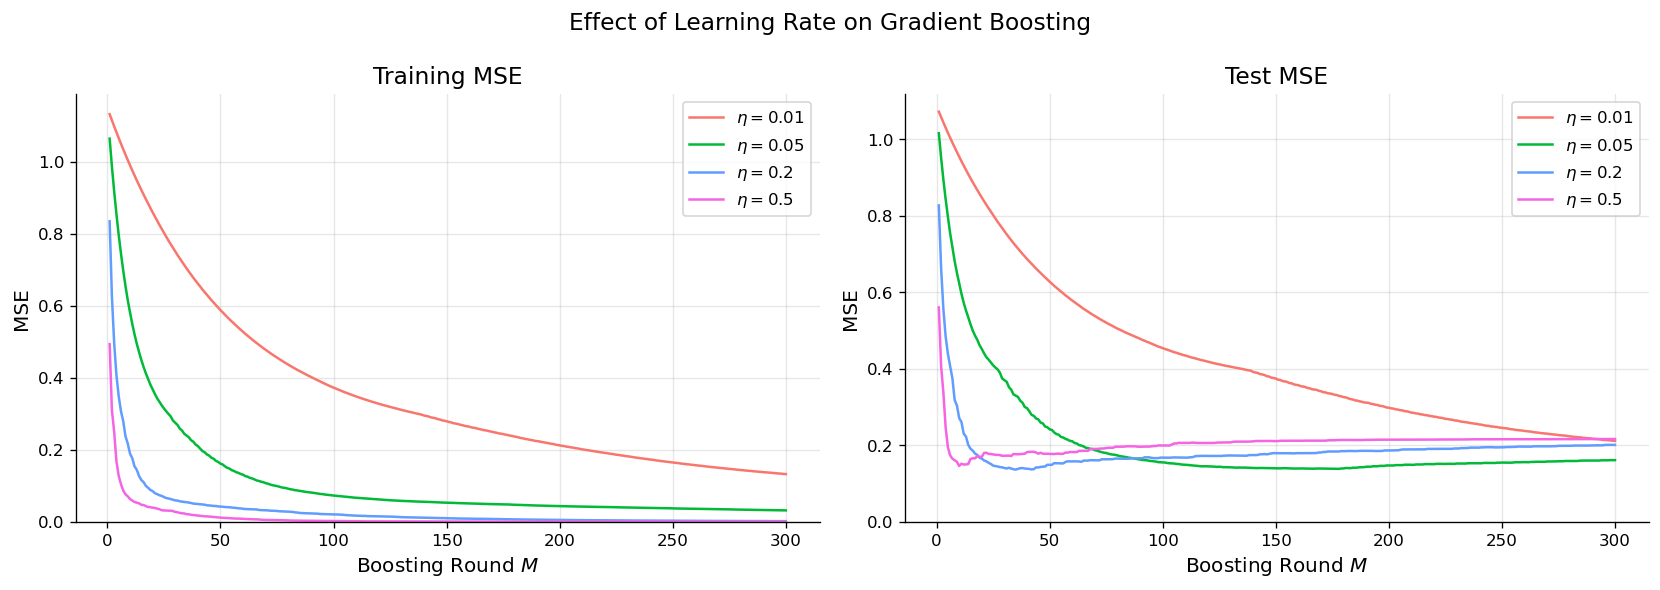

In [11]:
# Train/test split for this experiment
X_tr, X_te, y_tr, y_te = train_test_split(X_1d, y_1d, test_size=0.3, random_state=42)

learning_rates = [0.01, 0.05, 0.2, 0.5]
max_rounds = 300
colors_lr = [SALMON, EMERALD, PERIWINKLE, ORCHID]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, color in zip(learning_rates, colors_lr):
    train_errors = []
    test_errors = []
    f_tr = np.full(len(y_tr), y_tr.mean())
    f_te = np.full(len(y_te), y_tr.mean())

    for m in range(1, max_rounds + 1):
        res = y_tr - f_tr
        h = DecisionTreeRegressor(max_depth=2, random_state=m)
        h.fit(X_tr, res)
        f_tr += lr * h.predict(X_tr)
        f_te += lr * h.predict(X_te)
        train_errors.append(mean_squared_error(y_tr, f_tr))
        test_errors.append(mean_squared_error(y_te, f_te))

    rounds = np.arange(1, max_rounds + 1)
    axes[0].plot(rounds, train_errors, color=color, lw=1.5, label=f"$\\eta={lr}$")
    axes[1].plot(rounds, test_errors, color=color, lw=1.5, label=f"$\\eta={lr}$")

axes[0].set_title("Training MSE")
axes[1].set_title("Test MSE")
for ax in axes:
    ax.set_xlabel("Boosting Round $M$")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)

fig.suptitle("Effect of Learning Rate on Gradient Boosting", fontsize=14)
plt.tight_layout()
plt.show()

Key observations:

- **Training MSE** always decreases with more rounds — boosting can drive training error to zero given enough iterations.
- **Test MSE** eventually increases for large $\eta$ — the model overfits. With small $\eta$, the test error decreases more gradually but reaches a lower minimum.
- The optimal number of rounds depends on $\eta$: lower learning rates need more rounds but generalise better. In practice, we choose $M$ by **early stopping** on a validation set.

---

## 6. Professional Tools — scikit-learn

Now that we understand the theory, let us use scikit-learn's production-grade implementations. We compare several models on a more realistic regression task.

### 6.1 Model Comparison

We generate a moderately complex regression dataset with 5 features (3 informative, 2 noise) and compare:
- Single Decision Tree
- Random Forest
- Gradient Boosting (`GradientBoostingRegressor`)
- Histogram-based Gradient Boosting (`HistGradientBoostingRegressor`) — a faster implementation that bins continuous features into discrete histograms, similar to LightGBM/XGBoost.

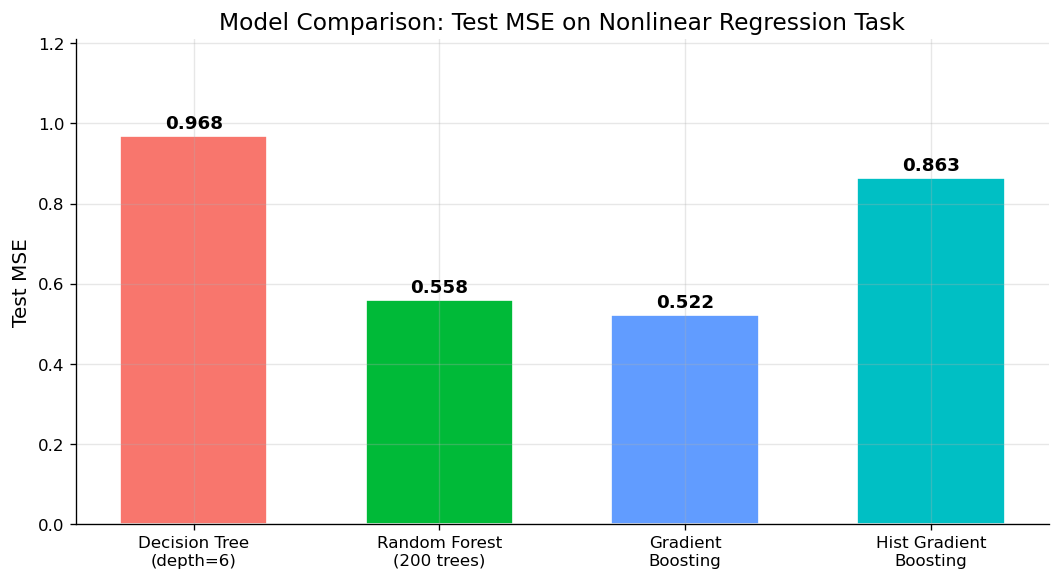

In [ ]:
# Generate a 5-feature regression dataset
n_samples = 600
X_full = rng.normal(size=(n_samples, 5))

# True function: nonlinear in first 3 features, features 4-5 are noise
y_full = (
    2 * np.sin(X_full[:, 0])
    + X_full[:, 1] ** 2
    + 0.5 * X_full[:, 0] * X_full[:, 2]
    + rng.normal(0, 0.5, n_samples)
)
feature_names = ["$x_1$", "$x_2$", "$x_3$", "$x_4$ (noise)", "$x_5$ (noise)"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42
)

models = {
    "Decision Tree\n(depth=6)": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest\n(200 trees)": RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=3, random_state=42
    ),
    "Gradient\nBoosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
    ),
    "Hist Gradient\nBoosting": HistGradientBoostingRegressor(
        max_iter=200, max_depth=4, learning_rate=0.1, random_state=42
    ),
}

test_mses = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_mses[name] = mean_squared_error(y_test, y_pred)

# Bar chart of test MSEs
fig, ax = plt.subplots(figsize=(9, 5))
names = list(test_mses.keys())
mses = list(test_mses.values())
colors = [SALMON, EMERALD, PERIWINKLE, CYAN]
bars = ax.bar(names, mses, color=colors, edgecolor="white", width=0.6)

for bar, mse in zip(bars, mses):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{mse:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("Test MSE")
ax.set_title("Model Comparison: Test MSE on Nonlinear Regression Task")
ax.set_ylim(0, max(mses) * 1.25)
plt.tight_layout()
plt.show()

The ensemble methods (Random Forest, Gradient Boosting, Histogram Gradient Boosting) substantially outperform the single decision tree. Among the ensembles, gradient boosting variants typically edge ahead on structured data with informative features.

### 6.2 Feature Importances

Tree-based models provide a natural measure of **feature importance**: for each feature, we sum the impurity decrease (Gini or MSE reduction) across all splits that use that feature, weighted by the number of samples reaching each split. Scikit-learn exposes this as `.feature_importances_`.

This is useful for understanding which features drive predictions, but has known limitations:

- **Biased toward high-cardinality features:** Features with many unique values (continuous features, high-cardinality categoricals) tend to receive higher importance because they offer more candidate splits.
- **Does not capture interactions well:** A feature may be important only in combination with another, but importances are computed marginally.
- **Correlated features split importance:** If two features are highly correlated, the importance is divided between them somewhat arbitrarily.

For more robust importance measures, consider **permutation importance** (shuffling a feature and measuring the increase in error) — but that is beyond our scope here.

The plot below shows feature importances from the Random Forest and Gradient Boosting models. We expect the three informative features ($x_1, x_2, x_3$) to dominate, with the two noise features ($x_4, x_5$) receiving low importance.

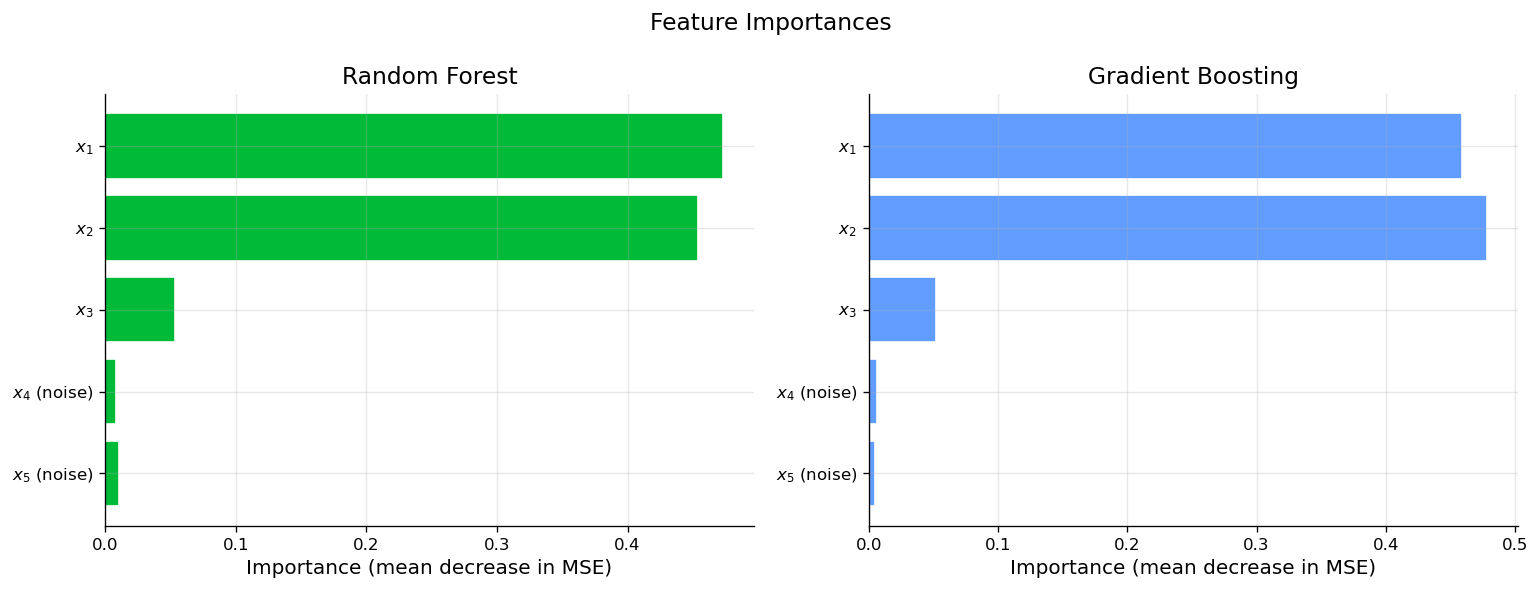

In [13]:
rf_model = models["Random Forest\n(200 trees)"]
gb_model = models["Gradient\nBoosting"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_pos = np.arange(len(feature_names))

# Random Forest importances
imp_rf = rf_model.feature_importances_
axes[0].barh(x_pos, imp_rf, color=EMERALD, edgecolor="white")
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(feature_names)
axes[0].set_xlabel("Importance (mean decrease in MSE)")
axes[0].set_title("Random Forest")
axes[0].invert_yaxis()

# Gradient Boosting importances
imp_gb = gb_model.feature_importances_
axes[1].barh(x_pos, imp_gb, color=PERIWINKLE, edgecolor="white")
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(feature_names)
axes[1].set_xlabel("Importance (mean decrease in MSE)")
axes[1].set_title("Gradient Boosting")
axes[1].invert_yaxis()

fig.suptitle("Feature Importances", fontsize=14)
plt.tight_layout()
plt.show()

As expected, the informative features ($x_1, x_2, x_3$) receive the lion's share of importance, while the noise features ($x_4, x_5$) get very little. Note that the relative ranking may differ slightly between Random Forest and Gradient Boosting — this is because the two algorithms interact with features differently (RF explores broadly via random subsets; GBM focuses greedily on the most impactful features).

---

## 7. Comparison — When to Use What

The table below summarises the key properties of the models we have studied in this module and the previous one (regularised linear models). This is not exhaustive, but captures the practical tradeoffs that guide model selection.

| Property                  |         OLS         |   Ridge   |    Lasso    |  Decision Tree   |  Random Forest  | Gradient Boosting  |
|:--------------------------|:-------------------:|:---------:|:-----------:|:----------------:|:---------------:|:------------------:|
| **Handles nonlinearity**  |         No          |    No     |     No      |       Yes        |       Yes       |        Yes         |
| **Handles interactions**  |       Manual        |  Manual   |   Manual    |    Automatic     |    Automatic    |     Automatic      |
| **Feature selection**     |         No          |    No     | Yes ($L_1$) |     Implicit     |    Implicit     |      Implicit      |
| **Robust to outliers**    |         No          |    No     |  Somewhat   |       Yes        |       Yes       |  Depends on loss   |
| **Interpretability**      |        High         |   High    |    High     |      Medium      |       Low       |        Low         |
| **Variance**              |         Low         |    Low    |     Low     |     **High**     |     Medium      |        Low         |
| **Bias**                  | High (if nonlinear) |  Medium   |   Medium    |       Low        |       Low       |        Low         |
| **Training speed**        |        Fast         |   Fast    |    Fast     |       Fast       |     Medium      |        Slow        |
| **Needs feature scaling** |         Yes         |    Yes    |     Yes     |        No        |       No        |         No         |
| **Hyperparameters**       |        None         | $\lambda$ |  $\lambda$  | depth, leaf size | $B$, $m$, depth | $M$, $\eta$, depth |

### Practical Guidance

- **Start simple:** If the relationship is roughly linear, Ridge or Lasso may be all you need — they are fast, interpretable, and well-understood.
- **Single decision trees** are excellent for **interpretability** (you can explain every prediction) but poor for **prediction accuracy** due to high variance. Use them for exploratory analysis or when interpretability is paramount.
- **Random Forests** are an excellent default for structured/tabular data: they require minimal tuning, handle nonlinearity and interactions automatically, and rarely overfit dramatically.
- **Gradient Boosting** (especially histogram-based variants like `HistGradientBoostingRegressor`, XGBoost, LightGBM) often achieves the **best predictive performance** on tabular data, but requires more careful tuning (learning rate, number of rounds, tree depth, regularisation).
- **No free lunch:** No model dominates in all settings. The best approach is always to try multiple models and compare via cross-validation.

---

## Key Takeaways

1. **Decision trees** partition feature space into axis-aligned regions via greedy recursive binary splitting, predicting a constant in each leaf. They are intuitive and interpretable but suffer from high variance.

2. **Impurity measures** (Gini index, entropy for classification; MSE for regression) quantify node "purity" and drive the splitting criterion. The optimal split at each node minimises the weighted child impurity.

3. **Overfitting** is the central weakness of single trees. It is controlled by stopping criteria (max depth, min samples per leaf) or cost-complexity pruning ($R_\alpha(T) = R(T) + \alpha|T|$).

4. **Random Forests** reduce variance by averaging $B$ decorrelated trees. Decorrelation comes from two sources: bootstrap sampling and random feature subsampling ($m \approx \sqrt{p}$ for classification, $m \approx p/3$ for regression). The ensemble variance is $\rho\sigma^2 + \frac{(1-\rho)}{B}\sigma^2$, so reducing $\rho$ is the key.

5. **Gradient Boosting** builds trees sequentially, each fitting the pseudo-residuals (negative gradient of the loss) of the current ensemble. It is equivalent to gradient descent in function space. Small learning rates with many rounds and early stopping yield the best generalisation.

6. **Feature importances** from tree ensembles provide useful but imperfect indicators of which features drive predictions. They are biased toward high-cardinality features and may misrepresent correlated features.

7. On structured/tabular data, **gradient boosting** (XGBoost, LightGBM, `HistGradientBoostingRegressor`) is often the state-of-the-art, while **Random Forests** are an excellent low-tuning default.

### Further Reading

- Hastie, Tibshirani, Friedman. *The Elements of Statistical Learning*, Chapters 9--10.
- Breiman, L. (2001). "Random Forests." *Machine Learning*, 45(1), 5--32.
- Friedman, J. H. (2001). "Greedy Function Approximation: A Gradient Boosting Machine." *Annals of Statistics*, 29(5), 1189--1232.
- scikit-learn documentation: [Ensemble Methods](https://scikit-learn.org/stable/modules/ensemble.html).

In [14]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
